In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load preprocessed data
data_dir = '../data/processed/'

corr_matrix = pd.read_csv(data_dir + 'X_train.csv').corr()

X_train = pd.read_csv(data_dir + 'X_train.csv').to_numpy()
X_val = pd.read_csv(data_dir + 'X_val.csv').to_numpy()
X_test = pd.read_csv(data_dir + 'X_test.csv').to_numpy()

y_train = pd.read_csv(data_dir + 'y_train.csv').to_numpy().flatten()
y_val = pd.read_csv(data_dir + 'y_val.csv').to_numpy().flatten()
y_test = pd.read_csv(data_dir + 'y_test.csv').to_numpy().flatten()

# Load raw data
raw_dir = '../data/raw/'
df = pd.read_csv(raw_dir + 'BankChurners.csv')

<Figure size 1000x800 with 0 Axes>

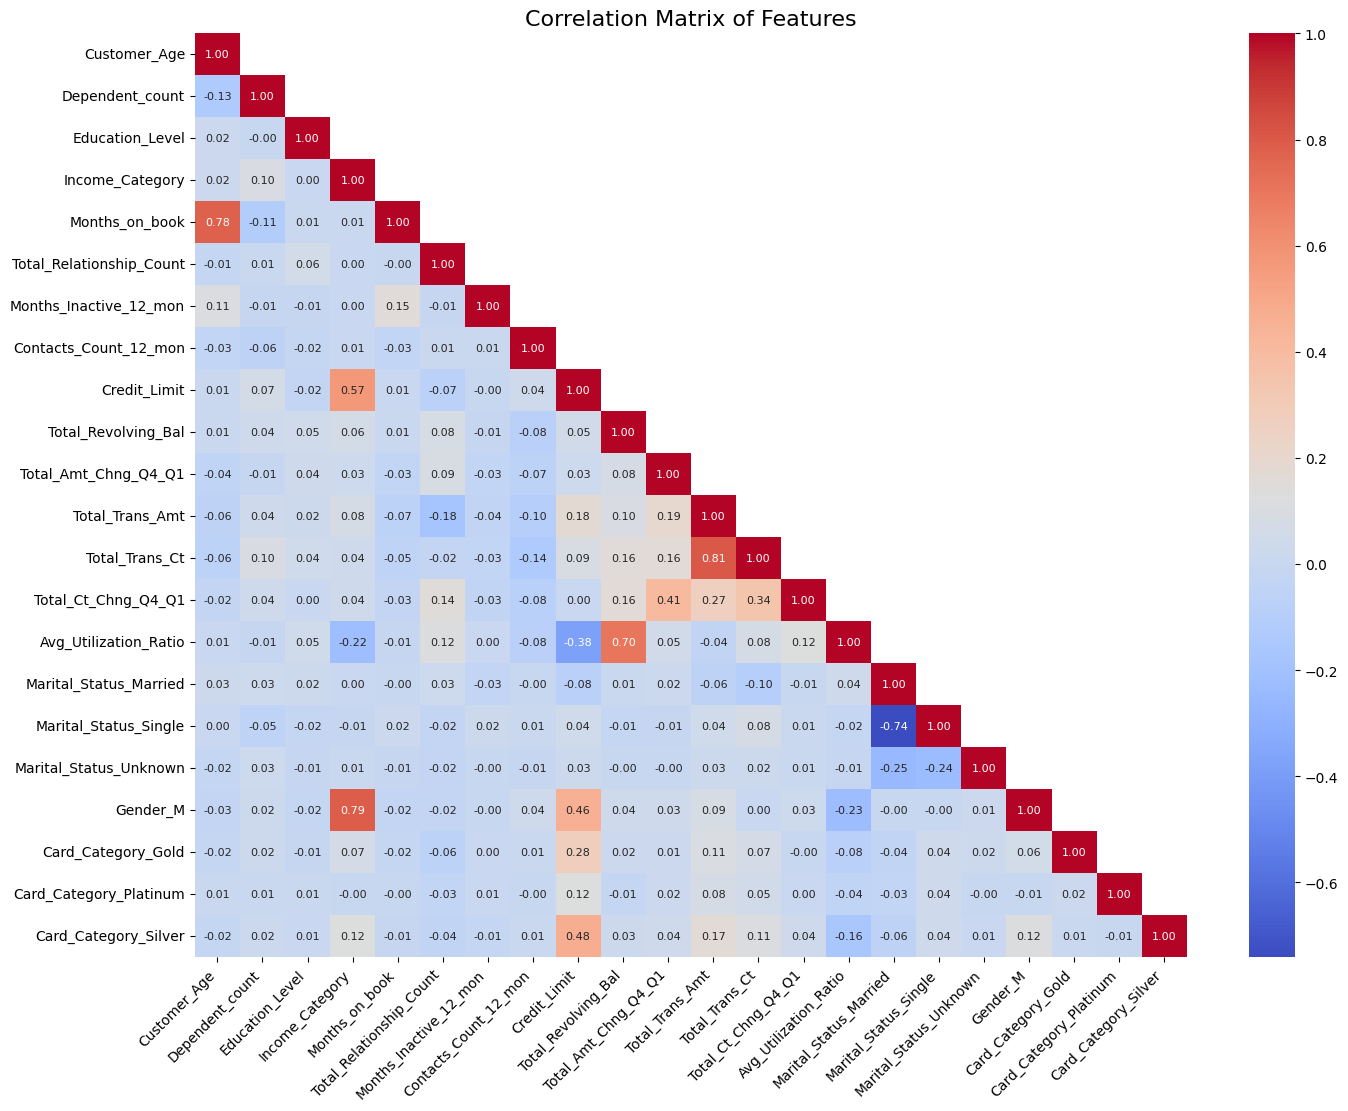

In [18]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
plt.figure(figsize=(10, 8))

plt.figure(figsize=(16, 12)) # Increase the width and height significantly

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm',
            annot_kws={"size": 8}) # Reduce font size (try values between 6 and 9)

plt.xticks(rotation=45, ha='right') # Rotate x-labels to prevent overlap
plt.title('Correlation Matrix of Features', fontsize=16) # Add title with larger font size
plt.show()

/var/folders/ys/vk08dbvx1j39094zzct3gd840000gn/T/ipykernel_99419/1730566716.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


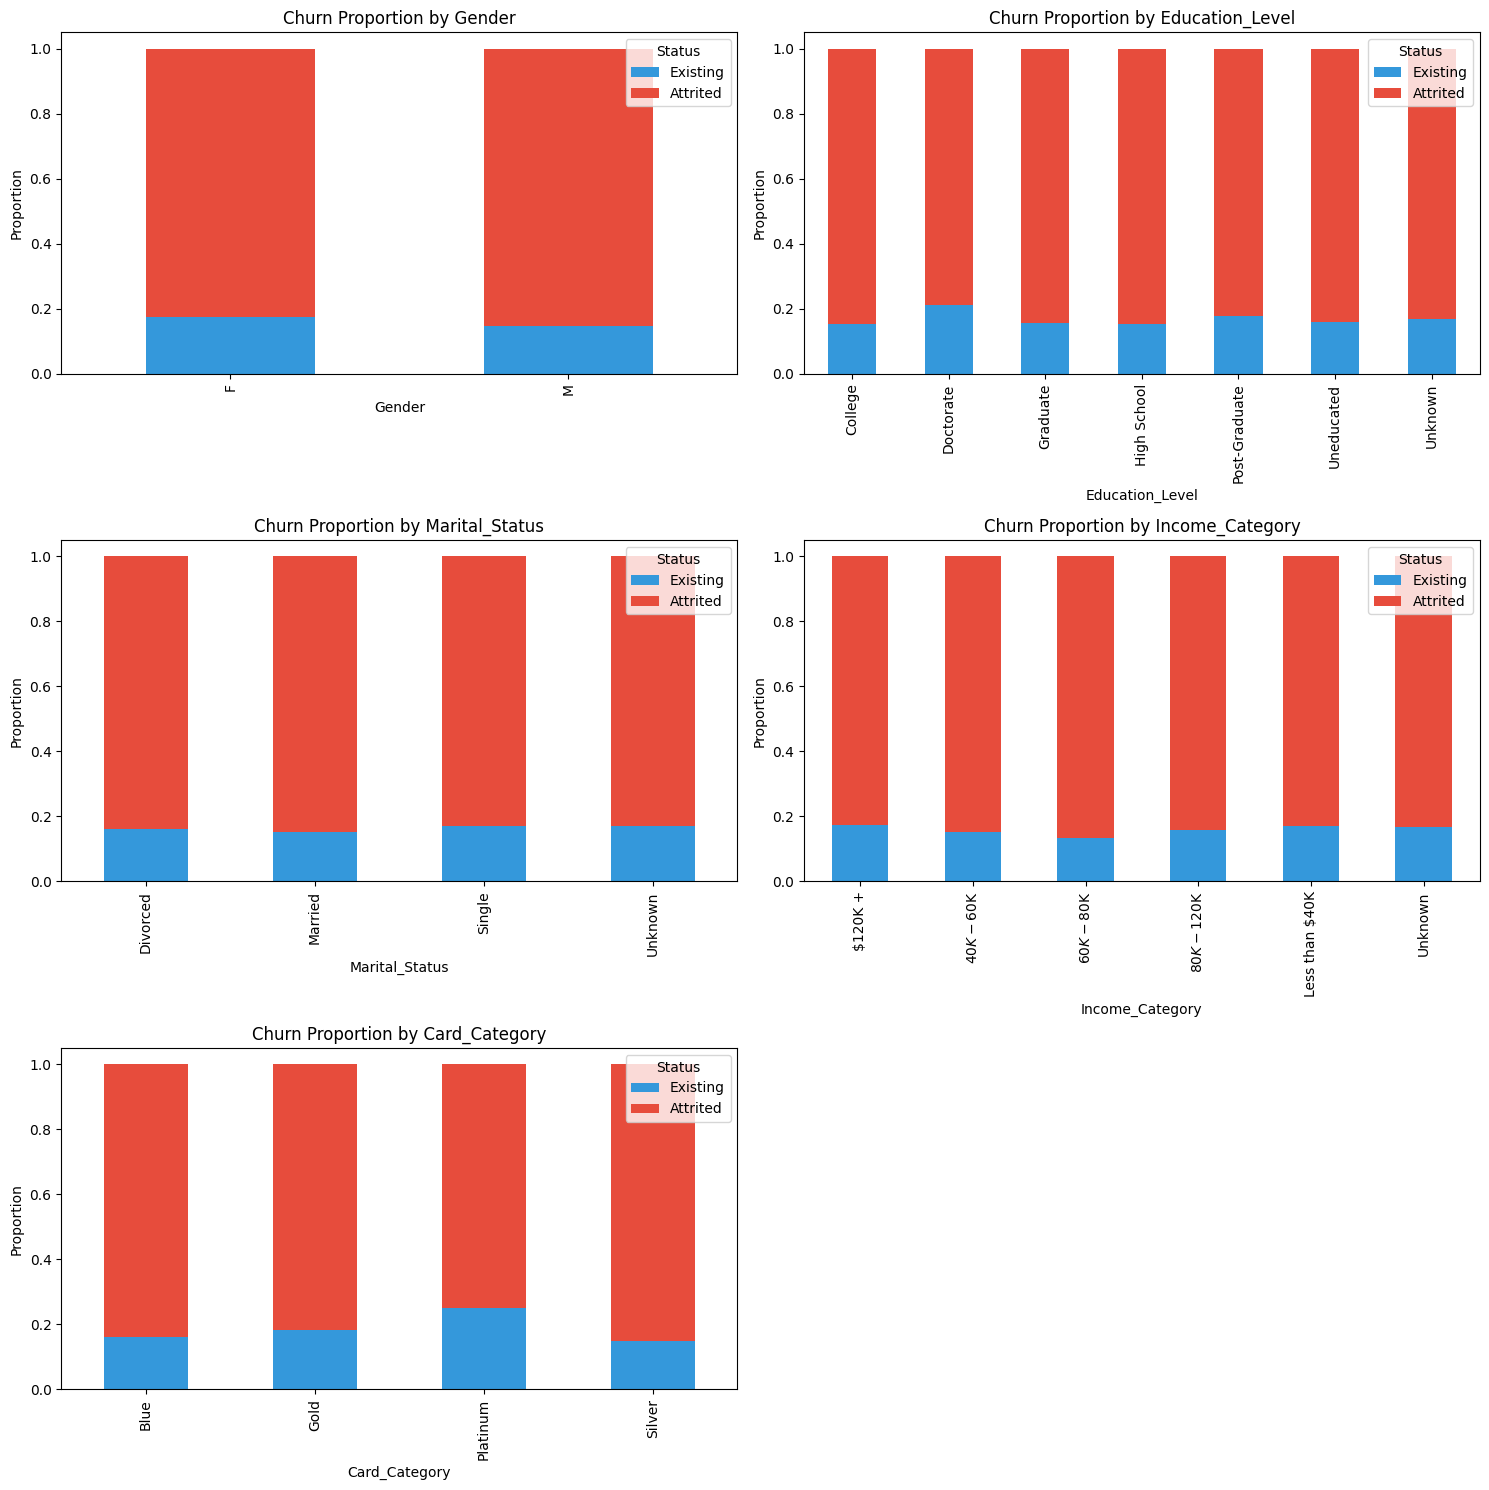

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'Attrition_Flag' in categorical_cols:
    categorical_cols.remove('Attrition_Flag')

# Calculate how many rows we need for a 2-column grid
num_rows = (len(categorical_cols) + 1) // 2
fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Create the cross-tab
    ct = pd.crosstab(df[col], df['Attrition_Flag'], normalize='index')
    
    # Plot as a stacked bar chart
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'])
    
    axes[i].set_title(f'Churn Proportion by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='Status', labels=['Existing', 'Attrited'], loc='upper right')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

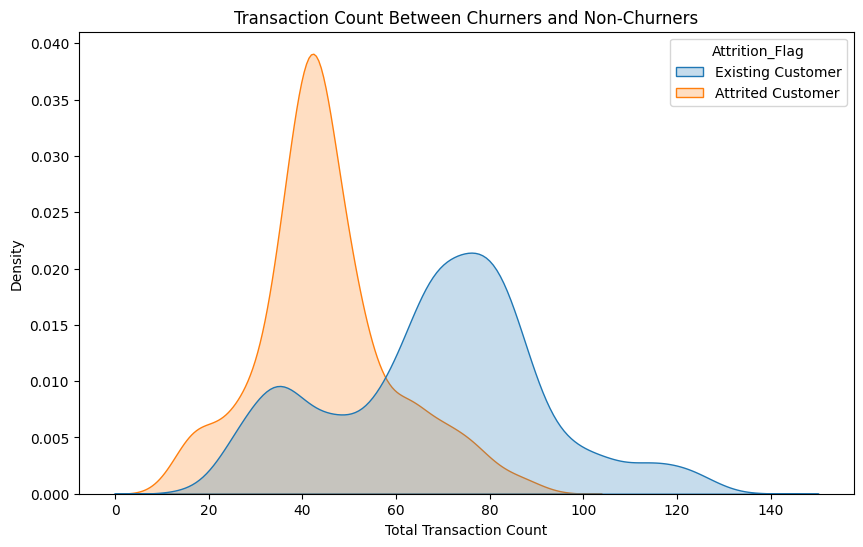

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Total_Trans_Ct', hue='Attrition_Flag', fill=True, common_norm=False)

plt.title('Transaction Count Between Churners and Non-Churners')
plt.xlabel('Total Transaction Count')
plt.show()

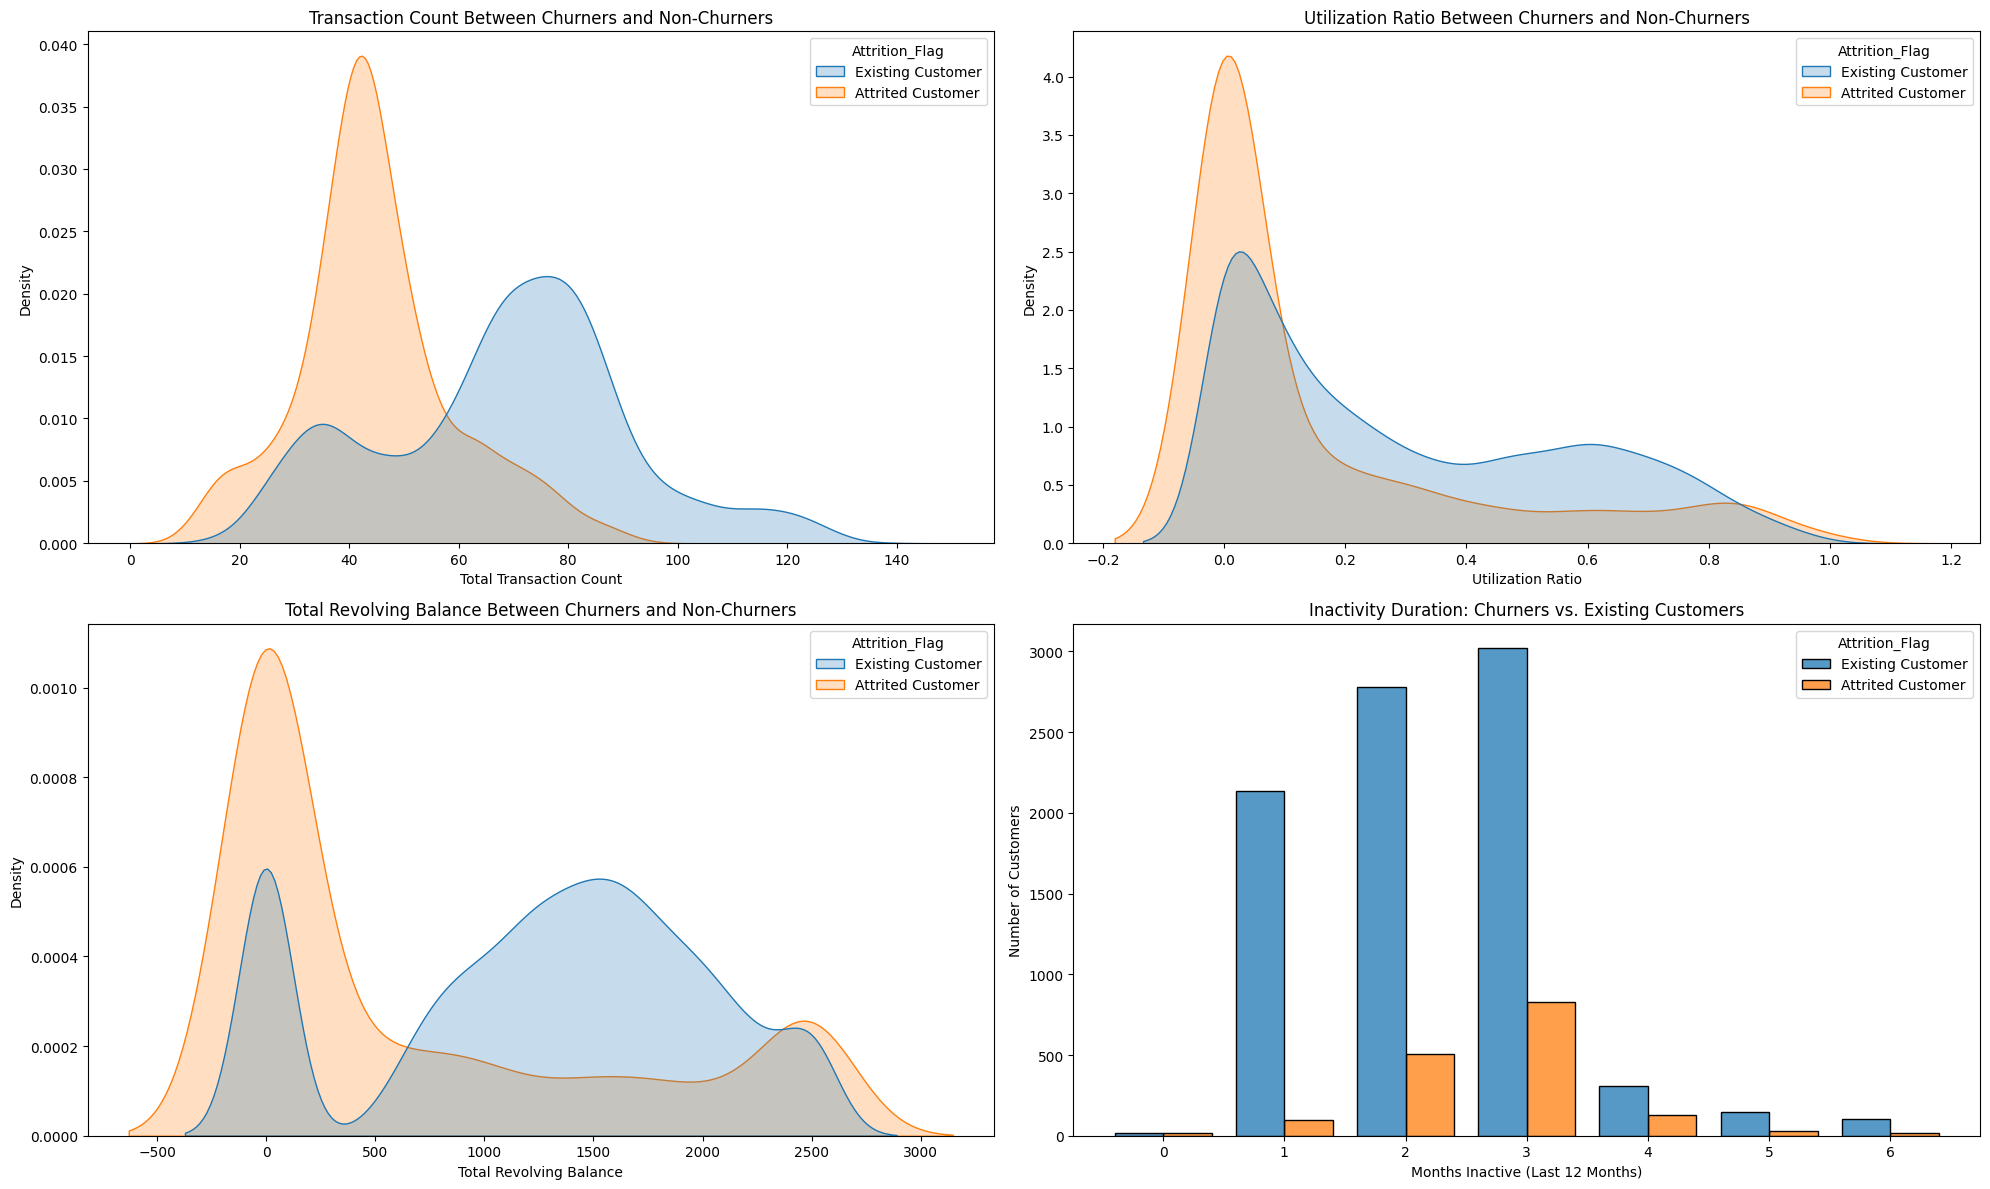

In [41]:
fig, axs = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Transaction Count
sns.kdeplot(data=df, x='Total_Trans_Ct', hue='Attrition_Flag', 
            fill=True, common_norm=False, ax=axs[0,0])
axs[0,0].set_title('Transaction Count Between Churners and Non-Churners')
axs[0,0].set_xlabel('Total Transaction Count')

# Plot 2: Utilization Ratio
sns.kdeplot(data=df, x='Avg_Utilization_Ratio', hue='Attrition_Flag', 
            fill=True, common_norm=False, ax=axs[0,1])
axs[0,1].set_title('Utilization Ratio Between Churners and Non-Churners')
axs[0,1].set_xlabel('Utilization Ratio')

# Plot 3: Total Revolving Balance
sns.kdeplot(data=df, x='Total_Revolving_Bal', hue='Attrition_Flag', 
            fill=True, common_norm=False, ax=axs[1, 0])
axs[1, 0].set_title('Total Revolving Balance Between Churners and Non-Churners')
axs[1, 0].set_xlabel('Total Revolving Balance')

# Plot 4: Months Inactive
sns.histplot(data=df, x='Months_Inactive_12_mon', hue='Attrition_Flag', 
             discrete=True, shrink=0.8, multiple="dodge", ax=axs[1, 1])
axs[1, 1].set_title('Inactivity Duration: Churners vs. Existing Customers')
axs[1, 1].set_xlabel('Months Inactive (Last 12 Months)')
axs[1, 1].set_ylabel('Number of Customers')

# Automatically adjust spacing between plots
plt.tight_layout()
plt.show()

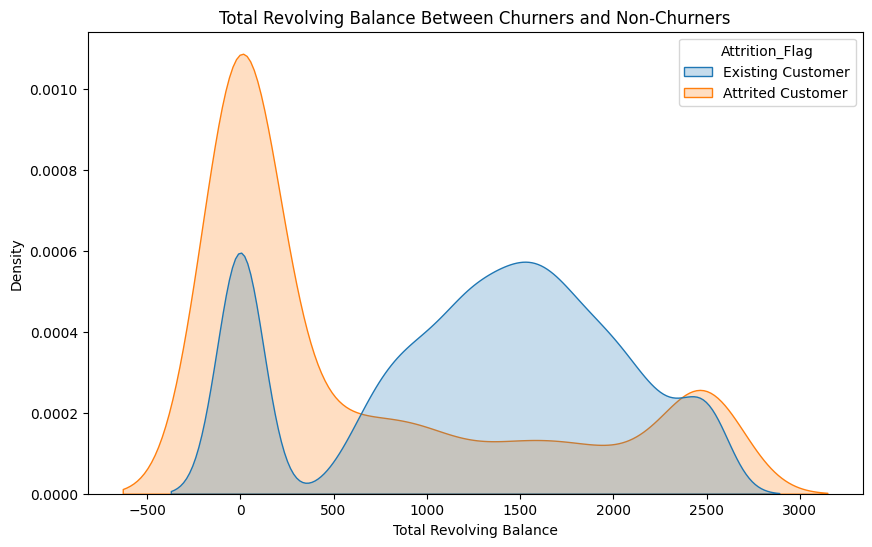

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Total_Revolving_Bal', hue='Attrition_Flag', fill=True, common_norm=False)

plt.title('Total Revolving Balance Between Churners and Non-Churners')
plt.xlabel('Total Revolving Balance')
plt.show()

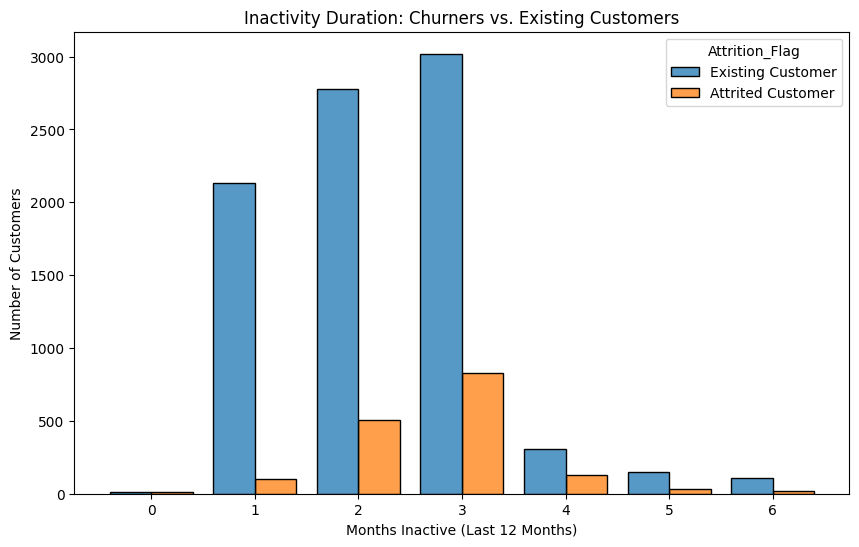

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Months_Inactive_12_mon', hue='Attrition_Flag', 
             discrete=True, shrink=0.8, multiple="dodge")

plt.title('Inactivity Duration: Churners vs. Existing Customers')
plt.xlabel('Months Inactive (Last 12 Months)')
plt.ylabel('Number of Customers')
plt.show()